# Part 1

Run this before running `analysis.rmd`.

In [2]:
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt
import matplotlib
import os
import re
import numpy as np
from collections import Counter

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Palatino', 'Palatino Linotype', 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

analysis_date = "261008"

In [3]:
# Demographics table
respondent_df = pd.read_csv(f"data/cleaned_respondent_level_{analysis_date}.csv")

# Decisions table
decision_df = pd.read_csv(f"data/cleaned_decision_level_{analysis_date}.csv")

# Labeled AI choices
ai_quality = pd.read_csv('data/AI_plan_quality_scores.csv').rename(columns={
    'patient_name': 'Case',
    'ai_condition': 'AI Label'
})
ai_quality['AI Label'] = ai_quality['AI Label'].replace({
    'treatment_recommendation': 'Recommended Treatment',
    'best_options': 'Options to Consider',
    'worst_options': 'Options to Avoid',
})

# All quality ratings
quality_scores_df = pd.read_csv("data/all_quality_ratings.csv").rename(columns={
    'Final': 'QualityScore',
    'E1': 'QualityScore_E1',
    'E2': 'QualityScore_E2',
    'E3': 'QualityScore_E3',
    'E4': 'QualityScore_E4',
    'E5': 'QualityScore_E5',
})

cases = decision_df['Case'].unique()
ai_interfaces = ['Recommended Treatment', 'Options to Consider', 'Options to Avoid']

In [4]:
print(np.quantile(respondent_df["Duration (in seconds)"], [0.25, 0.5, 0.75]) / 60)
print(np.quantile(decision_df["Page Submit Time"], [0.25, 0.5, 0.75]))

[12.875      17.59166667 27.675     ]
[ 73.4255 106.398  158.723 ]


In [9]:
cases = decision_df['Case'].unique()

ai_interfaces = ['Recommended Treatment', 'Options to Consider', 'Options to Avoid']
all_agreements_by_decision = []
all_concordance_labels = []

for interface_idx, ai_interface in enumerate(ai_interfaces):
    
    agreements_by_decision = []
    no_ai = decision_df[decision_df['AIInterface'] == 'No AI']
    with_ai = decision_df[decision_df['AIInterface'] == ai_interface]

    # decisions up to 16 to accommodate conditional decisions
    all_decisions = np.arange(1, 17)
    
    concordance_counts_with_ai = {}
    concordance_counts_no_ai = {}
    
    for case in cases:
        no_counts = no_ai[no_ai['Case'] == case]['decision_num'].value_counts().reindex(all_decisions, fill_value=0)
        with_counts = with_ai[with_ai['Case'] == case]['decision_num'].value_counts().reindex(all_decisions, fill_value=0)

        if quality_scores_df[quality_scores_df['Case'] == case]['Decision'].max() == 14:
            decision_arrangement = np.array([
                [10, 1, 4, 7],
                [np.nan, np.nan, 13, 14],
                [11, 2, 5, 8],
                [12, 3, 6, 9]
            ])
            fluid_labels = ["Diu.", "No IVF", "<1L IVF", "≥1L IVF"]
            vaso_labels = ["No VP", "0-1 VP (cond.)", "1 VP", "2 VP"]
        elif quality_scores_df[quality_scores_df['Case'] == case]['Decision'].max() == 16:
            decision_arrangement = np.array([
                [10, 1, 4, 7],
                [np.nan, np.nan, 13, 15],
                [11, 2, 5, 8],
                [np.nan, np.nan, 14, 16],
                [12, 3, 6, 9]
            ])
            fluid_labels = ["Diu.", "No IVF", "<1L IVF", "≥1L IVF"]
            vaso_labels = ["No VP", "0-1 VP (cond.)", "1 VP", "1-2 VP (cond.)", "2 VP"]
        else:
            assert False
            
        def taxi_distance_fn(loc_1, loc_2):
            dist = 0
            for axis in range(2):
                els_between = np.arange(min(loc_1[axis], loc_2[axis]) + 1, max(loc_1[axis], loc_2[axis]))
                # print(loc_1, loc_2, axis, els_between)
                if len(els_between) == 0 or loc_1[1 - axis] != loc_2[1 - axis]:
                    dist += np.abs(loc_1[axis] - loc_2[axis])
                else:
                    dist += (~np.isnan(np.take(decision_arrangement, loc_1[1 - axis], axis=1 - axis)[els_between])).sum() + 1
            return dist
        
        def min_axis_distance_fn(loc_1, loc_2):
            dists = []
            for axis in range(2):
                els_between = np.arange(min(loc_1[axis], loc_2[axis]) + 1, max(loc_1[axis], loc_2[axis]))
                # print(loc_1, loc_2, axis, els_between)
                if len(els_between) == 0 or loc_1[1 - axis] != loc_2[1 - axis]:
                    dists.append(np.abs(loc_1[axis] - loc_2[axis]))
                else:
                    dists.append((~np.isnan(np.take(decision_arrangement, loc_1[1 - axis], axis=1 - axis)[els_between])).sum() + 1)
            return min(dists)
        
        best_ai_decisions = ai_quality[(ai_quality['AI Label'] == 'Recommended Treatment') & (ai_quality['Case'] == case)]['decision_num'].unique().tolist()    
        ai_decisions = ai_quality[(ai_quality['AI Label'] == ai_interface) & (ai_quality['Case'] == case)]['decision_num'].unique().tolist()
        ai_decision_locs = [np.argwhere(decision_arrangement == dec)[0] for dec in ai_decisions]
        best_ai_decision_locs = [np.argwhere(decision_arrangement == dec)[0] for dec in best_ai_decisions]
        decision_concordance_labels = {}
        for decision_num in all_decisions:
            loc = np.argwhere(decision_arrangement == decision_num)
            if len(loc) == 0: continue
            loc = loc[0]
            if any((loc == selected_loc).all() for selected_loc in ai_decision_locs):
                decision_concordance_labels[decision_num] = "Mentioned"
            elif any(taxi_distance_fn(loc, selected_loc) <= 1 for selected_loc in ai_decision_locs):
                decision_concordance_labels[decision_num] = "Adjacent"
            else:
                decision_concordance_labels[decision_num] = "None"
                            
        # print(case, ai_decision_locs)
        all_concordance_labels += [{"AIInterface": ai_interface, "Case": case, "decision_num": k, "ConcordanceType": v} for k, v in decision_concordance_labels.items()]
        
all_concordance_labels = pd.DataFrame(all_concordance_labels)
all_concordance_labels.to_csv("data/AI_concordance_types.csv", index=False)
all_concordance_labels

,AIInterface,Case,decision_num,ConcordanceType
0,Recommended Treatment,Deborah,1,Mentioned
1,Recommended Treatment,Deborah,2,Adjacent
2,Recommended Treatment,Deborah,3,None
3,Recommended Treatment,Deborah,4,Adjacent
4,Recommended Treatment,Deborah,5,None
...,...,...,...,...
259,Options to Avoid,Mike,10,Adjacent
260,Options to Avoid,Mike,11,None
261,Options to Avoid,Mike,12,None
262,Options to Avoid,Mike,13,Adjacent


In [10]:
min_quality = quality_scores_df.groupby("Case")["QualityScore"].min().rename("MinQuality")
max_quality = quality_scores_df.groupby("Case")["QualityScore"].max().rename("MaxQuality")

decision_df = pd.merge(decision_df, pd.concat([min_quality, max_quality], axis=1).reset_index(), how='left', on='Case')
decision_df['IsBestScore'] = decision_df['QualityScore'] >= decision_df['MaxQuality'] # np.minimum(decision_df['MaxQuality'], 6)

# Simulate expected decision quality of following AI
np.random.seed(1234)

smoothing_factor = 0.05
n_trials = 1000

results = []
for ai_label in ['No AI', *ai_interfaces]:
    for case in cases:
        # Create a smoothed probability distribution over No AI actions
        decision_dist = decision_df[(decision_df['AIInterface'] == 'No AI') & (decision_df['Case'] == case)]['decision_num'].value_counts(normalize=True) 
        possible_decs = quality_scores_df[quality_scores_df['Case'] == case]['Decision'].unique()
        smoothing = pd.Series({d: 1 / len(possible_decs) for d in possible_decs}, name='smoothing')
        decision_dist = pd.merge(smoothing * smoothing_factor,
                                 decision_dist * (1 - smoothing_factor),
                                 left_index=True,
                                 right_index=True,
                                 how='left').fillna(0).sum(axis=1)
        
        matches = ai_quality[(ai_quality['AI Label'] == ai_label) & (ai_quality['Case'] == case)]
        if ai_label == 'Options to Avoid':
            decision_dist = decision_dist[~decision_dist.index.isin(matches['decision_num'])]
        elif ai_label != 'No AI':
            decision_dist = decision_dist[decision_dist.index.isin(matches['decision_num'])]
        decision_dist /= decision_dist.sum()
        print(ai_label, case, decision_dist)
            
        for t in range(n_trials):
            results.append({
                'AIInterface': ai_label,
                'Case': case,
                'decision_num': np.random.choice(decision_dist.index, p=decision_dist.values),
            })

simulated_df = pd.DataFrame(results)
simulated_df = pd.merge(simulated_df, quality_scores_df, how='left', left_on=['Case', 'decision_num'], right_on=['Case', 'Decision'])
simulated_df = pd.merge(simulated_df, pd.concat([min_quality, max_quality], axis=1).reset_index(), how='left', on='Case')
simulated_df['IsBestScore'] = simulated_df['QualityScore'] >= simulated_df['MaxQuality'] # np.minimum(simulated_df['MaxQuality'], 6)

no_ai_quality = simulated_df[simulated_df['AIInterface'] == 'No AI'].groupby('Case').agg({'QualityScore': 'mean'}).reset_index().rename(columns={
    'QualityScore': 'NoAIQuality'
})

average_simulated_quality = simulated_df.groupby(["AIInterface", "Case"]).agg({"QualityScore": "mean"}).reset_index().rename(columns={"QualityScore": "SimulatedQualityScore"})
average_simulated_quality = pd.merge(average_simulated_quality, no_ai_quality, how="left", on="Case")
average_simulated_quality["RelativeQuality"] = average_simulated_quality["SimulatedQualityScore"] - average_simulated_quality["NoAIQuality"]

df_no_ai_qual = pd.merge(decision_df, average_simulated_quality, how='left', on=['AIInterface', 'Case'])
df_no_ai_qual.to_csv(f"data/decisions_with_relative_quality_{analysis_date}.csv", index=False)
print("Humans + AI")
print(df_no_ai_qual.groupby("AIInterface")["IsBestScore"].mean())
print("Always Following AI")
print(simulated_df.groupby("AIInterface")["IsBestScore"].mean())

No AI Deborah 1     0.003125
2     0.138839
3     0.057411
4     0.057411
5     0.111696
6     0.030268
7     0.030268
8     0.003125
9     0.057411
10    0.003125
11    0.030268
12    0.003125
13    0.193125
14    0.111696
15    0.057411
16    0.111696
dtype: float64
No AI Heather 1     0.031513
2     0.562395
3     0.003571
4     0.003571
5     0.003571
6     0.003571
7     0.003571
8     0.003571
9     0.003571
10    0.003571
11    0.143277
12    0.003571
13    0.227101
14    0.003571
dtype: float64
No AI Esther 1     0.027930
2     0.466392
3     0.003571
4     0.027930
5     0.052289
6     0.003571
7     0.003571
8     0.052289
9     0.003571
10    0.003571
11    0.101007
12    0.003571
13    0.174084
14    0.076648
dtype: float64
No AI Richard 1     0.026875
2     0.216875
3     0.311875
4     0.003125
5     0.003125
6     0.003125
7     0.003125
8     0.003125
9     0.003125
10    0.050625
11    0.145625
12    0.193125
13    0.026875
14    0.003125
15    0.003125
16    0.003125


In [11]:
# Now split into good and bad quality AI advice
advice_quality_dfs = []

for ai_interface in ai_interfaces:
    cutoff = 0 # decision_df[df_no_ai_qual['AIInterface'] == ai_interface].drop_duplicates('Case')['NoAIQuality'].median()
    good_advice_cases = average_simulated_quality[(average_simulated_quality['RelativeQuality'] >= cutoff) & 
                                    (average_simulated_quality['AIInterface'] == ai_interface)]['Case']
    good_advice_data = pd.concat([
        decision_df[(decision_df['AIInterface'] == 'No AI') & 
                      decision_df['Case'].isin(good_advice_cases)],
        decision_df[(decision_df['AIInterface'] == ai_interface) & 
                      decision_df['Case'].isin(good_advice_cases)]
    ]).assign(SimulatedAIHighQuality=True)
    good_advice_data = pd.merge(good_advice_data,
                                average_simulated_quality[average_simulated_quality['AIInterface'] == ai_interface][['Case', 'RelativeQuality']],
                                how='left',
                                on='Case')
    good_advice_data = pd.merge(good_advice_data,
                                all_concordance_labels[all_concordance_labels['AIInterface'] == ai_interface].drop(columns=['AIInterface']),
                                how='left',
                                on=['Case', 'decision_num'])
    
    bad_advice_cases = average_simulated_quality[(average_simulated_quality['RelativeQuality'] < cutoff) & 
                                    (average_simulated_quality['AIInterface'] == ai_interface)]['Case']
    bad_advice_data = pd.concat([
        decision_df[(decision_df['AIInterface'] == 'No AI') & 
                      decision_df['Case'].isin(bad_advice_cases)],
        decision_df[(decision_df['AIInterface'] == ai_interface) & 
                      decision_df['Case'].isin(bad_advice_cases)]

    ]).assign(SimulatedAIHighQuality=False)
    bad_advice_data = pd.merge(bad_advice_data,
                                average_simulated_quality[average_simulated_quality['AIInterface'] == ai_interface][['Case', 'RelativeQuality']],
                                how='left',
                                on='Case')
    bad_advice_data = pd.merge(bad_advice_data,
                                all_concordance_labels[all_concordance_labels['AIInterface'] == ai_interface].drop(columns=['AIInterface']),
                                how='left',
                                on=['Case', 'decision_num'])
    advice_qual_df = pd.concat([good_advice_data, bad_advice_data]).assign(AgreementWith=ai_interface)
    advice_qual_df = advice_qual_df.assign(HasAI=advice_qual_df['AIInterface'] != 'No AI',
                                           ConcordanceCombined=pd.Series(np.where(advice_qual_df['AIInterface'] == 'No AI', 'A', 'B'), index=advice_qual_df.index) + pd.Series(
                                                                        np.where(advice_qual_df['ConcordanceType'] == 'Mentioned', 'A', 'B') if ai_interface != 'Options to Avoid' else 
                                                                        np.where(advice_qual_df['ConcordanceType'] == 'Mentioned', 'B', 'A'), index=advice_qual_df.index),
                                           Agreement=np.where(advice_qual_df['ConcordanceType'] == 'Mentioned', 1, 0) if ai_interface != 'Options to Avoid' else 
                                                                        np.where(advice_qual_df['ConcordanceType'] == 'Mentioned', 0, 1), index=advice_qual_df.index)
    print(good_advice_cases)
    print(advice_qual_df[['AIInterface', 'SimulatedAIHighQuality']].value_counts())
    advice_qual_df.to_csv(f"data/advice_quality_{ai_interface}_{analysis_date}.csv", index=False)
    advice_quality_dfs.append(advice_qual_df)


22       Mike
23    Richard
Name: Case, dtype: str
AIInterface            SimulatedAIHighQuality
Recommended Treatment  False                     201
No AI                  False                     149
Recommended Treatment  True                       94
No AI                  True                       76
Name: count, dtype: int64
12    Deborah
16       Mike
17    Richard
Name: Case, dtype: str
AIInterface          SimulatedAIHighQuality
Options to Consider  True                      173
                     False                     157
No AI                False                     114
                     True                      111
Name: count, dtype: int64
6     Deborah
7      Esther
9    Margaret
Name: Case, dtype: str
AIInterface       SimulatedAIHighQuality
Options to Avoid  False                     169
                  True                      160
No AI             True                      115
                  False                     110
Name: count, dtype: int64


# Part 2
First, use R script (`analysis.rmd`) to analyze the data generated above. Then proceed:

In [12]:
best_choice_means = pd.read_csv("result_data/best_choice_bootstrap_mean_cis.csv", index_col=0)
best_choice_means

,AIInterface,HumanAI,mean,ci.lower,ci.upper
1,No AI,Human,0.471482,0.406648,0.542350
2,Options to Avoid,Human,0.428907,0.375464,0.476137
3,Options to Avoid,Simulated,0.432269,0.380577,0.477663
4,Options to Consider,Human,0.477748,0.425539,0.527757
5,Options to Consider,Simulated,0.311810,0.278379,0.339557
6,Recommended Treatment,Human,0.562832,0.508064,0.621974
7,Recommended Treatment,Simulated,0.318419,0.288011,0.344967


In [13]:
real_means = decision_df.groupby("AIInterface")["IsBestScore"].mean()
best_choice_means.loc[best_choice_means["HumanAI"] == "Human", "mean"] = pd.merge(best_choice_means[best_choice_means["HumanAI"] == "Human"][["AIInterface"]], real_means,
                                                                                  right_index=True, left_on="AIInterface", how="left")["IsBestScore"]
best_choice_means

,AIInterface,HumanAI,mean,ci.lower,ci.upper
1,No AI,Human,0.471111,0.406648,0.542350
2,Options to Avoid,Human,0.428571,0.375464,0.476137
3,Options to Avoid,Simulated,0.432269,0.380577,0.477663
4,Options to Consider,Human,0.478788,0.425539,0.527757
5,Options to Consider,Simulated,0.311810,0.278379,0.339557
6,Recommended Treatment,Human,0.562712,0.508064,0.621974
7,Recommended Treatment,Simulated,0.318419,0.288011,0.344967


In [14]:
print(decision_df.groupby("AIInterface")["IsBestScore"].sum())
print(decision_df.groupby("AIInterface")["IsBestScore"].count())

AIInterface
No AI                    106
Options to Avoid         141
Options to Consider      158
Recommended Treatment    166
Name: IsBestScore, dtype: int64
AIInterface
No AI                    225
Options to Avoid         329
Options to Consider      330
Recommended Treatment    295
Name: IsBestScore, dtype: int64


[('Human', 'No AI', AIInterface       No AI
HumanAI           Human
mean           0.471111
ci.lower       0.406648
ci.upper        0.54235
Name: 1, dtype: object), (None, None, None), ('Human', 'Recommended Treatment', AIInterface    Recommended Treatment
HumanAI                        Human
mean                        0.562712
ci.lower                    0.508064
ci.upper                    0.621974
Name: 6, dtype: object), (None, None, None), ('Human', 'Options to Consider', AIInterface    Options to Consider
HumanAI                      Human
mean                      0.478788
ci.lower                  0.425539
ci.upper                  0.527757
Name: 4, dtype: object), (None, None, None), ('Human', 'Options to Avoid', AIInterface    Options to Avoid
HumanAI                   Human
mean                   0.428571
ci.lower               0.375464
ci.upper               0.476137
Name: 2, dtype: object)]


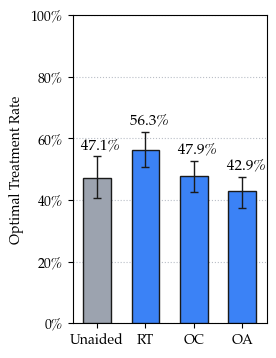

In [15]:


import matplotlib.pyplot as plt
import numpy as np

df = best_choice_means.copy()

# default colors if not provided
colors = {
    "Recommended Treatment": "#3b82f6", # "#be185d", # "#10b981",
    "Options to Consider": "#3b82f6", #"#a855f7", #"#06b6d4",
    "Options to Avoid": "#3b82f6", #"#a5b4fc", #, "#6366f1",
    "No AI": "#9ca3af",
}
# colors = {
#     "Human": "#3b82f6",
#     "Simulated": "#9ca3af"
# }

groups = [
    [("Human", "No AI")],
    [("Human", "Recommended Treatment")], #, ("Simulated", "Recommended Treatment")],
    [("Human", "Options to Consider")], #, ("Simulated", "Options to Consider")],
    [("Human", "Options to Avoid")], #, ("Simulated", "Options to Avoid")],
]

label_fmt = lambda human_ai, condition: {"No AI": "Unaided", "Recommended Treatment": "RT", "Options to Consider": "OC", "Options to Avoid": "OA"}[condition] # if condition == "No AI" else condition
gap_between_groups = 0.4
bar_height = 0.6

# build final ordered list of (group, label) pairs and y positions
pairs = []
for i, g in enumerate(groups):
    for lbl in g:
        row = df[(df['HumanAI'] == lbl[0]) & (df['AIInterface'] == lbl[1])]
        if not row.empty:
            pairs.append((lbl[0], lbl[1], row.iloc[0]))
    # add a spacer after each group except last
    if i < len(groups) - 1:
        pairs.append((None, None, None))  # spacer marker
print(pairs)

# compute y positions
y_positions = []
colors_for_plot = []
interface_labels = []
means = []
lower_err = []
upper_err = []
tick_positions = []
tick_labels = []

y = 0
left_y = 0
for pi, p in enumerate(pairs):
    if p[0] is None:
        tick_positions.append((y + left_y - 1) * 0.5)
        tick_labels.append(label_fmt(pairs[pi - 1][0], pairs[pi - 1][1]))
        y += gap_between_groups
        left_y = y
        continue
    y_positions.append(y)
    interface_labels.append({"Human": "Observed Decisions", "Simulated": "Simulated (Always Following AI)"}.get(p[0], p[0]) if p[1] == "Recommended Treatment" else None)
    colors_for_plot.append(colors.get(p[1], "#777777"))
    row = p[-1]
    m = row["mean"]
    l = row["mean"] - row["ci.lower"]
    u = row["ci.upper"] - row["mean"]
    means.append(m)
    lower_err.append(l)
    upper_err.append(u)
    y += 1
tick_positions.append((y + left_y - 1) * 0.5)
tick_labels.append(label_fmt(pairs[-1][0], pairs[-1][1]))

# convert to arrays
y_pos = np.array(y_positions)
means = np.array(means) * 100.0
lower_err = np.array(lower_err) * 100.0
upper_err = np.array(upper_err) * 100.0
err = np.vstack([lower_err, upper_err])

# plot
fig, ax = plt.subplots(figsize=(2.5, 4))
for y, m, e, c, label in zip(y_pos, means, err.T, colors_for_plot, interface_labels):
    ax.errorbar(x=y, y=m, yerr=e.reshape(2, 1), color='0.1', marker='none',
                capsize=3, elinewidth=1, zorder=10)
    ax.bar(x=y, height=m, color=c, ec='0.1', lw=1, zorder=5, label=label)

# y ticks and labels: use label_col but include grouping by spacing visually
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels) #, rotation=45, ha='right')
ax.set_xlim(y_pos.min() - bar_height * 0.5 - gap_between_groups, y_pos.max() + bar_height * 0.5 + gap_between_groups)
# ax.invert_yaxis()

# annotate percentage to right of bars
for i, (y, upper, mean) in enumerate(zip(y_pos, upper_err, means)):
    offset = 5 if i == 5 else 1
    ax.text(y, mean + upper + offset if not np.isnan(upper) else mean + offset,
            "  {:.1%}".format(mean / 100),
            va='bottom', ha='center', fontsize=11)

ax.set_ylabel("Optimal Treatment Rate")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter())
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
ax.grid(visible=True, axis='y', which='major', color='#9ca3af', linestyle=':', alpha=0.7)
# ax.legend()

# plt.tight_layout()
plt.savefig("figures/best_choice_rate_bar.svg")
plt.show()


0 None Mentioned 8.0% 26.8% 18.8%
0 None Adjacent 33.3% 33.2% -0.1%
0 None None 58.7% 40.0% -18.7%
0 True Mentioned 22.4% 64.9% 42.5%
0 True Adjacent 48.7% 21.3% -27.4%
0 True None 28.9% 13.8% -15.1%
0 False Mentioned 0.7% 9.0% 8.3%
0 False Adjacent 25.5% 38.8% 13.3%
0 False None 73.8% 52.2% -21.6%
{'Mentioned': np.float64(-0.225), 'Adjacent': np.float64(1.1749999999999998), 'None': np.float64(2.5749999999999997)}
{'Mentioned': np.float64(-0.45), 'Adjacent': np.float64(0.95), 'None': np.float64(2.3499999999999996)}
{'Mentioned': np.float64(0.0), 'Adjacent': np.float64(1.4), 'None': np.float64(2.8)}
1 None Mentioned 15.6% 38.5% 22.9%
1 None Adjacent 47.1% 36.1% -11.1%
1 None None 37.3% 25.5% -11.9%
1 True Mentioned 29.7% 57.2% 27.5%
1 True Adjacent 52.3% 34.1% -18.1%
1 True None 18.0% 8.7% -9.3%
1 False Mentioned 1.8% 17.8% 16.1%
1 False Adjacent 42.1% 38.2% -3.9%
1 False None 56.1% 43.9% -12.2%
{'Mentioned': np.float64(-0.225), 'Adjacent': np.float64(1.1749999999999998), 'None': np.flo

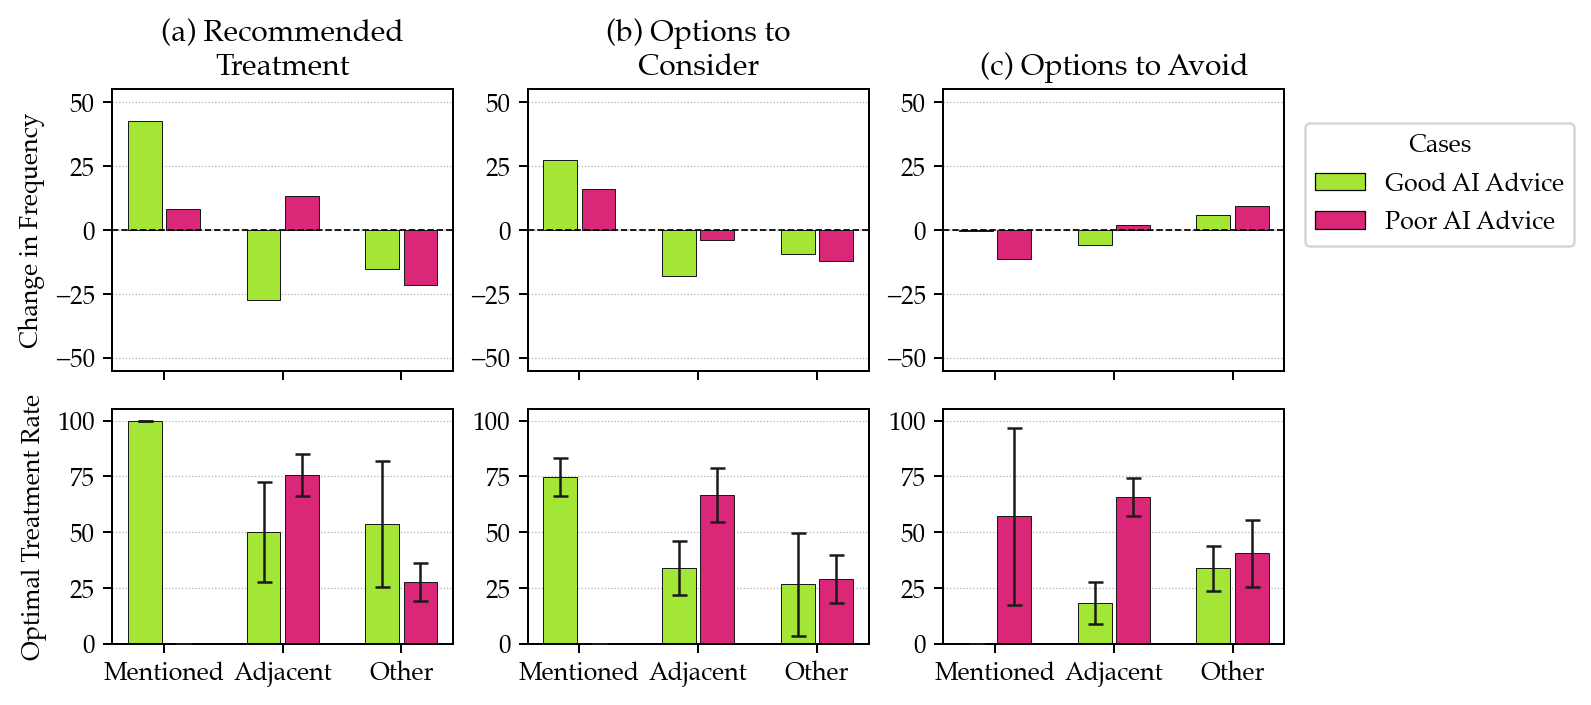

In [17]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import gridspec
import numpy as np
import pandas as pd
import matplotlib

INTERFACE_LABELS = ["(a) Recommended\nTreatment", "(b) Options to\nConsider", "(c) Options to Avoid"]
def plot_interface_rows_with_heatmaps(alice_dfs, out_path='figures/interface_rows_with_heatmaps_aligned.png'):
    """
    Transposed visualization for each AI interface (one vertical panel / column):
     - Top: percent-point differences in concordance frequency (With AI - No AI),
             plotted as three small vertical bars for Good (left) and Poor (right).
     - Bottom: 2x3 grid heatbands (Good col, Poor col) x (Mentioned, Adjacent, None),
             each band shows proportion across QualityScore 1..7 computed only on rows where HasAI == True.
    """
    advice_quality_dfs = alice_dfs
    concordance_order = ['Mentioned', 'Adjacent', 'None']
    concordance_labels = ['Mentioned', 'Adjacent', 'Other']
    colors = {True: '#a3e635', False: '#db2777', None: '#3b82f6'}
    quality_to_show = [True, False] # [None, True, False]
    quality_labels = ["Good AI Advice", "Poor AI Advice"]

    n_panels = len(advice_quality_dfs)
    fig_w = 2.8 * n_panels
    fig = plt.figure(figsize=(fig_w, 4), dpi=180)
    outer = gridspec.GridSpec(2, n_panels, height_ratios=[1.2, 1], hspace=0.15, wspace=0.22)

    cmap = plt.cm.RdBu # plt.cm.Blues
    vmin, vmax = 0.0, 1.0

    for col_idx, df in enumerate(advice_quality_dfs):
        df = df.copy()
        df['SimulatedAIHighQuality'] = df['SimulatedAIHighQuality'].astype(bool)
        df['HasAI'] = df['HasAI'].astype(bool)

        # compute diffs for each (sim_high, concordance)
        diffs = {}
        for sim_high in [None, True, False]:
            for c in concordance_order:
                sub_with = df[(df['HasAI'] == True)]
                sub_no = df[(df['HasAI'] == False)]
                if sim_high is not None:
                    sub_with = sub_with[(sub_with['SimulatedAIHighQuality'] == sim_high)]
                    sub_no = sub_no[(sub_no['SimulatedAIHighQuality'] == sim_high)]
                prop_with = sub_with['ConcordanceType'].value_counts(normalize=True).reindex(concordance_order, fill_value=0)[c] if len(sub_with) > 0 else 0.0
                prop_no = sub_no['ConcordanceType'].value_counts(normalize=True).reindex(concordance_order, fill_value=0)[c] if len(sub_no) > 0 else 0.0
                diffs[(sim_high, c)] = (prop_with - prop_no) * 100.0
                print(col_idx, sim_high, c, "{:.1%}".format(prop_no), "{:.1%}".format(prop_with), "{:.1%}".format(prop_with - prop_no))

        spacing = 0.45
        bar_w = 0.4
        group_width = spacing * len(quality_to_show) + 0.5

        centers = (np.arange(len(concordance_order))) * group_width - 0.5 * spacing
        centers_map = {c: p for c, p in zip(concordance_order, centers)}
        print(centers_map)

        ax_top = fig.add_subplot(outer[0, col_idx])
        for i_sim, sim_high in enumerate(quality_to_show):  # 0 left = Good, 1 right = Poor

            x_positions_all = (np.arange(len(concordance_order))) * group_width + (i_sim - 1) * spacing
            left_map = {c: p for c, p in zip(concordance_order, x_positions_all)}

            for c in concordance_order:
                x_left = left_map[c]
                diff_left = diffs[(sim_high, c)]
                ax_top.bar(x_left, diff_left, width=bar_w, color=colors[sim_high], edgecolor='0.1', linewidth=0.4, zorder=2)

        ax_top.set_xticks([centers_map['Mentioned'], centers_map['Adjacent'], centers_map['None']])
        ax_top.set_xticklabels([])

        ax_top.axhline(0, color='k', linestyle='--', linewidth=0.7)
        if col_idx == 0:
            ax_top.set_ylabel('Change in Frequency')

        ax_top.set_ylim(-55, 55)
        ax_top.yaxis.grid(True, linestyle=':', linewidth=0.5, which='both')
        ax_top.yaxis.set_major_locator(MultipleLocator(25))
        ax_top.set_title(INTERFACE_LABELS[col_idx])

        # bottom: 2 columns (Good, Poor)
        ax_bottom = fig.add_subplot(outer[1, col_idx])

        for i_sim, sim_high in enumerate(quality_to_show):  # 0 left = Good, 1 right = Poor

            x_positions_all = (np.arange(len(concordance_order))) * group_width + (i_sim - 1) * spacing
            left_map = {c: p for c, p in zip(concordance_order, x_positions_all)}
            print(left_map)

            bar_w = 0.4
            for c in concordance_order:
                x_left = left_map[c]
                rows = df[(df['HasAI'] == True) & (df['ConcordanceType'] == c)]
                if sim_high is not None:
                    rows = rows[rows['SimulatedAIHighQuality'] == sim_high]
                mean = rows['IsBestScore'].mean() * 100
                ci = 1.96 * rows['IsBestScore'].std() / np.sqrt(len(rows)) * 100
                ax_bottom.bar(x_left, mean, width=bar_w, color=colors[sim_high],
                            edgecolor='0.1', linewidth=0.4, zorder=2)
                ax_bottom.errorbar(x_left, mean, yerr=ci, fmt='none', color='0.1',
                            elinewidth=1, capsize=3, zorder=3)

        ax_bottom.set_xticks([centers_map['Mentioned'], centers_map['Adjacent'], centers_map['None']])
        ax_bottom.set_xticklabels(concordance_labels) #, rotation=45, ha='right')

        ax_bottom.set_ylim(0, 105)
        if col_idx == 0:
            ax_bottom.set_ylabel('Optimal Treatment Rate')

        ax_bottom.yaxis.grid(True, linestyle=':', linewidth=0.5, which='major')
        ax_bottom.yaxis.set_major_locator(MultipleLocator(25))


    # legend for concordance colors (keeps consistency with left bars)
    handles = [mpatches.Patch(facecolor=colors[c], edgecolor='k', lw=0.5, label=l) for c, l in zip(quality_to_show, quality_labels)]
    fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.1, 0.85, 0, 0), title='Cases')

    # plt.subplots_adjust(wspace=0.05)
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()

plot_interface_rows_with_heatmaps(advice_quality_dfs, 'figures/agreement_by_advice_quality.svg')